# First practical work in Deep Learning course - Part 2
**Name:** Maha Kahla 


The same steps as in the first part. The deep learning model is different.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import sys
import time
from torchvision import datasets
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import os
from PIL import Image
from torch.utils.data import DataLoader


from IPython.display import clear_output

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
transform = T.Compose([
    T.Resize((128, 128)),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.4688, 0.4635, 0.3433], std=[0.2352, 0.2299, 0.2442])
])

In [4]:
train_dataset = datasets.ImageFolder('archive/Vegetable_Images/train', transform=transform)
val_dataset = datasets.ImageFolder('archive/Vegetable_Images/validation', transform=transform)
test_dataset = datasets.ImageFolder('archive/Vegetable_Images/test', transform=transform)


batchSize = 32
train_dataloader = DataLoader(train_dataset, batch_size=batchSize, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=batchSize, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=batchSize, shuffle=False, drop_last=True)

The used pre-trained architecture is resnet101, which is a convolutional neural network for image classification and object detection. It has 101 layers and it's suitable for a large dataset. Resnet101 is part of residual networks family which are easier to optimize, and can gain accuracy from considerably increased depth.

In [6]:
weights = torchvision.models.ResNet101_Weights.DEFAULT
model = torchvision.models.resnet101(weights=weights)


In [7]:
# model

In [8]:
summary(model.to(device),(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           9,408
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]           4,096
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          16,384
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           Conv2d-13          [-1, 256, 32, 32]          16,384
      BatchNorm2d-14          [-1, 256,

After obtaining the pre-trained model, we need to disable gradient counting in the pre-trained weights, which means that parameters with disabled gradient counting will not be updated during subsequent training. 

In [6]:
# Freeze model parameters
for param in model.parameters():
    param.requires_grad = False

In [10]:
for name, param in model.named_parameters():
    print(name, "\t", param.requires_grad)

conv1.weight 	 False
bn1.weight 	 False
bn1.bias 	 False
layer1.0.conv1.weight 	 False
layer1.0.bn1.weight 	 False
layer1.0.bn1.bias 	 False
layer1.0.conv2.weight 	 False
layer1.0.bn2.weight 	 False
layer1.0.bn2.bias 	 False
layer1.0.conv3.weight 	 False
layer1.0.bn3.weight 	 False
layer1.0.bn3.bias 	 False
layer1.0.downsample.0.weight 	 False
layer1.0.downsample.1.weight 	 False
layer1.0.downsample.1.bias 	 False
layer1.1.conv1.weight 	 False
layer1.1.bn1.weight 	 False
layer1.1.bn1.bias 	 False
layer1.1.conv2.weight 	 False
layer1.1.bn2.weight 	 False
layer1.1.bn2.bias 	 False
layer1.1.conv3.weight 	 False
layer1.1.bn3.weight 	 False
layer1.1.bn3.bias 	 False
layer1.2.conv1.weight 	 False
layer1.2.bn1.weight 	 False
layer1.2.bn1.bias 	 False
layer1.2.conv2.weight 	 False
layer1.2.bn2.weight 	 False
layer1.2.bn2.bias 	 False
layer1.2.conv3.weight 	 False
layer1.2.bn3.weight 	 False
layer1.2.bn3.bias 	 False
layer2.0.conv1.weight 	 False
layer2.0.bn1.weight 	 False
layer2.0.bn1.bias 	 

Then we replace the final layer to with new one, suitable for our task match our output features in the dataset. These new layers will be trained in the next step using the same loops as in the first part of the laboratory work.

In [7]:
model.fc = nn.Linear(model.fc.in_features, 15)

In [8]:
vegetables = model
vegetables.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vegetables.parameters(), lr=0.001, weight_decay=0.001)

In [9]:
imgs, labels = next(iter(train_dataloader))

# print("\nThe first sample in the batch:")
# img = imgs[0].squeeze()
# label = labels[0].item()

# plt.figure(figsize=(3, 3))
# plt.imshow(img.T, cmap="gray")
# plt.title(label)
# plt.axis("off")
# plt.show()


imgs, labels = imgs.to(device), labels.to(device)
pred = vegetables(imgs)
print('Output size:')
print(pred.shape)

loss = criterion(pred,torch.squeeze(labels))
print('Loss:')
print(loss)

Output size:
torch.Size([32, 15])
Loss:
tensor(2.7744, device='cuda:0', grad_fn=<NllLossBackward0>)


In [10]:
num_epochs = 12

In [11]:
def train_NN():

    trainLoss = torch.zeros(num_epochs)
    valLoss = torch.zeros(num_epochs)
    trainAcc = torch.zeros(num_epochs)
    valAcc = torch.zeros(num_epochs)
    

    for epochi in range(num_epochs):

        vegetables.train()
        batch_train_loss = []
        batch_train_acc = []
        for imgs, labels in train_dataloader:
            imgs, labels  = imgs.to(device), labels.to(device)

            pred = vegetables(imgs)
            loss = criterion(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())



        trainLoss[epochi] = np.mean(batch_train_loss)
        trainAcc[epochi] = 100 * np.mean(batch_train_acc)
        
        vegetables.eval()
        with torch.no_grad():
            batch_val_loss = []
            batch_val_acc = []
            for imgs, labels in val_dataloader:
                imgs, labels = imgs.to(device), labels.to(device)


                pred = vegetables(imgs)
                loss = criterion(pred, labels)

                batch_val_loss.append(loss.item())
                batch_val_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())


            valLoss[epochi] = np.mean(batch_val_loss)
            valAcc[epochi] = 100 * np.mean(batch_val_acc)

        sys.stdout.write(f"\rFinished epoch: {epochi+1}/{num_epochs}")

    print("    Done!!!")
    return trainLoss, valLoss, trainAcc, valAcc,  vegetables

In [12]:
def test_NN():

    with torch.no_grad():

        batch_test_loss = []
        batch_test_acc = []
        for imgs, labels in test_dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            pred = vegetables(imgs)
            loss = criterion(pred, labels)

            batch_test_loss.append(loss.item())
            batch_test_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())

        testLoss = np.mean(batch_test_loss)
        testAcc = 100 * np.mean(batch_test_acc)

    print("Done!!!")
    return testLoss, testAcc

In [17]:
trainLoss, valLoss, trainAcc, valAcc, vegetables = train_NN()

Finished epoch: 12/12    Done!!!


In [18]:
testLoss, testAcc = test_NN()

Done!!!


In [19]:
testAcc

98.62231182795699

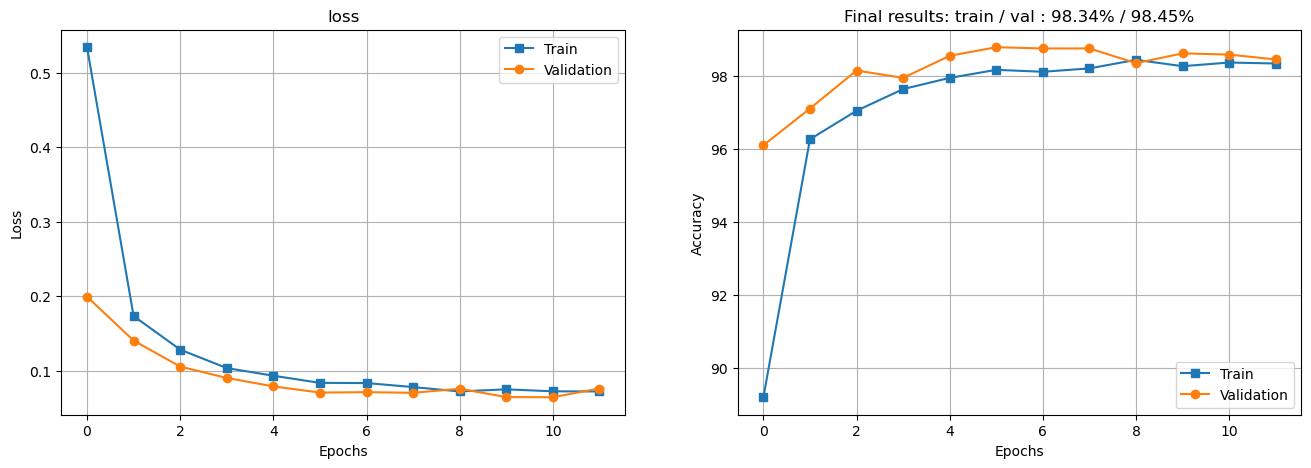

In [20]:

fig, a = plt.subplots(1, 2, figsize=(16, 5))

a[0].plot(trainLoss, 's-', label='Train')
a[0].plot(valLoss, 'o-', label='Validation')

a[0].set_xlabel('Epochs')
a[0].set_ylabel('Loss')
a[0].set_title('loss')
a[0].legend()
a[0].grid(True)

a[1].plot(trainAcc, 's-', label='Train')
a[1].plot(valAcc, 'o-', label='Validation')
a[1].set_xlabel('Epochs')
a[1].set_ylabel('Accuracy')
a[1].set_title(f'Final results: train / val : {trainAcc[-1]:.2f}% / {valAcc[-1]:.2f}%')
a[1].legend()
a[1].grid(True)

plt.show()

We notice that the model is already solving the problem with a high accuracy but we can also apply fine tuning to the layers in the hope that this will improve the quality a bit more, this is done by firstly unfreezing the previously frozen weights, then calling the training loop.

In [14]:
for param in model.parameters():
    param.requires_grad = True

In [15]:
num_epochs = 3

I used a small number of epochs due to the limited source of gpu and that it takes a long time. At the end, using the accuracy score the accuracy of the model is 93 % after fine tuning. The first result was better but I think it's because it requires a larger number of epochs.

In [16]:
# fine tune all layers
trainLoss, valLoss, trainAcc, valAcc, vegetables = train_NN()  

Finished epoch: 3/3    Done!!!


In [15]:
# test_loader = DataLoader(test, batch_size=32, shuffle=False, drop_last=True)
y_true = []
y_pred = []
for imgs, labels in test_dataloader:
    outputs = model(imgs.to(device))
    y_true.append(labels.numpy())
    preds = outputs.argmax(dim=1)
    y_pred.append(preds.detach().cpu().numpy())

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score


y_true = np.stack(y_true).flatten()
y_pred = np.stack(y_pred).flatten()

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.93


In [18]:
torch.save(vegetables.state_dict(), "model_weights3.pth")

In [8]:
model = model
model.load_state_dict(torch.load("model_weights3.pth"))
model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
test_dataloader = DataLoader(test_dataset, batch_size=batchSize, shuffle=True, drop_last=True)

In [10]:
imgs, labels = next(iter(test_dataloader))

# tt = T.Compose([
#     T.Resize((128, 128)),T.ToTensor()])
# imgs = tt(im)
print("imgs shape: ", imgs.shape)

imgs shape:  torch.Size([32, 3, 128, 128])


In [11]:
# get output
pred = model(imgs.to(device))
print("pred shape: ", pred.shape)

pred shape:  torch.Size([32, 15])


In [12]:
import numpy as np

pred = pred[:10].detach()
print("Prediction(1 sample):\n", pred[0])

digits = np.argmax(pred.cpu().numpy(), axis=1)
print("Predicted class: ", digits[0])

Prediction(1 sample):
 tensor([-0.7724,  8.0170, -3.2769, -1.0428, -0.0222, -0.0690, -4.0636, -3.2787,
         0.2064, -3.0339, -3.1911, -3.6041,  0.0927, -0.6383, -1.3434],
       device='cuda:0')
Predicted class:  1


In [13]:
# remove axis
imgs = torch.squeeze(imgs)
print("imgs shape (after squeeze): ", imgs.shape)

# take 10 first images
imgs = imgs[:10]
print("imgs shape: ", imgs.shape)

imgs shape (after squeeze):  torch.Size([32, 3, 128, 128])
imgs shape:  torch.Size([10, 3, 128, 128])


/tmp/ipykernel_4062/3011130217.py:10: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  plt.imshow(img.T, cmap="gray")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8966899..1.902306].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9478631..2.5607185].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.016094..2.3198357].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0160

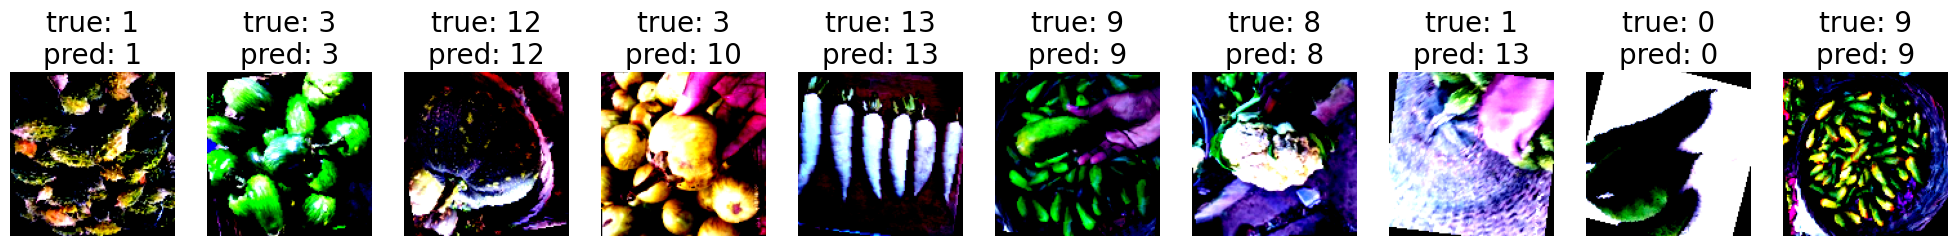

In [14]:
plt.figure(figsize=(25.0, 25.0))
for i in range(10):
    img = imgs[i]

    plt.subplot(1, 10, i + 1)
    plt.title(
        f"true: {labels[i].numpy()}\npred: {digits[i]}", fontsize=20
    )  # predicted and real values
    plt.axis("off")
    plt.imshow(img.T, cmap="gray")